In [1]:
import numpy as np
import scipy
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.cosmology import Planck18 as cosmo
from functools import partial
import time
import pyccl as ccl
import sacc
import pandas as pd
import os
import sacc

## Capish data

In [2]:
capish_mock = "./mock_DC2like_data.fits"
lensing_profiles = Table.read(capish_mock)
display(lensing_profiles)

binned_radius_Mpc,binned_profiles,binned_weights,cluster_redshift,cluster_richness
float64[7],float64[7],float64[7],float64,float64
1.205798096999757 .. 3.398405744893644,50711955084569.54 .. -6720814759063.933,184.0 .. 1309.0,0.5196392785571142,22.299356752873127
1.2020419816001218 .. 3.396236112611125,51099836755271.55 .. -10554255462271.828,110.0 .. 730.0,0.7541082164328657,22.778533937162834
1.206815880026978 .. 3.3884604240850646,20680507038731.676 .. -5152430447961.257,225.0 .. 1530.0,0.4655310621242485,25.25432956247126
1.212015572090798 .. 3.396147640693361,30716780729788.402 .. -10027553101110.785,162.0 .. 1096.0,0.5697394789579158,20.9726155487306
1.2120709637201514 .. 3.3888255668918705,-2409549397597.335 .. 19394184032183.707,301.0 .. 2195.0,0.38136272545090183,22.486298430718705
1.2097945394156278 .. 3.38640164179692,-30945625914556.754 .. -38672556032501.76,87.0 .. 756.0,0.7400801603206413,23.65947443448947
1.2029845242989934 .. 3.3852265315481747,19383706987615.22 .. 7972079712498.405,558.0 .. 3943.0,0.2651302605210421,21.8908894459416
1.2104220356366309 .. 3.392343493119293,-36151421852817.586 .. 5516328689892.831,415.0 .. 2742.0,0.3312625250501002,28.97166328310095
1.2021213785608513 .. 3.3807772679951635,-11991453885592.959 .. -4147454717769.6416,152.0 .. 1047.0,0.5897795591182364,20.417413652353808


In [3]:
def binning(corner): return [[corner[i],corner[i+1]] for i in range(len(corner)-1)]

z_corner = np.array([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
Z_bin = np.array(binning(z_corner))
rich_corner = np.array([20, 35, 70, 100, 200])
rich_corner = np.array([r for r in rich_corner])
Obs_bin = np.array(binning(rich_corner))
Obs_bin_center = np.mean(Obs_bin, axis=1)
Z_bin_center = np.mean(Z_bin, axis=1)

<>:50: SyntaxWarning: invalid escape sequence '\l'
<>:50: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_996844/959164318.py:50: SyntaxWarning: invalid escape sequence '\l'
  plt.errorbar(x_mean, y_mean, y_err_mean, label = f'{rich_bin[0]:.0f} < $\lambda$ < {rich_bin[1]:.0f}')


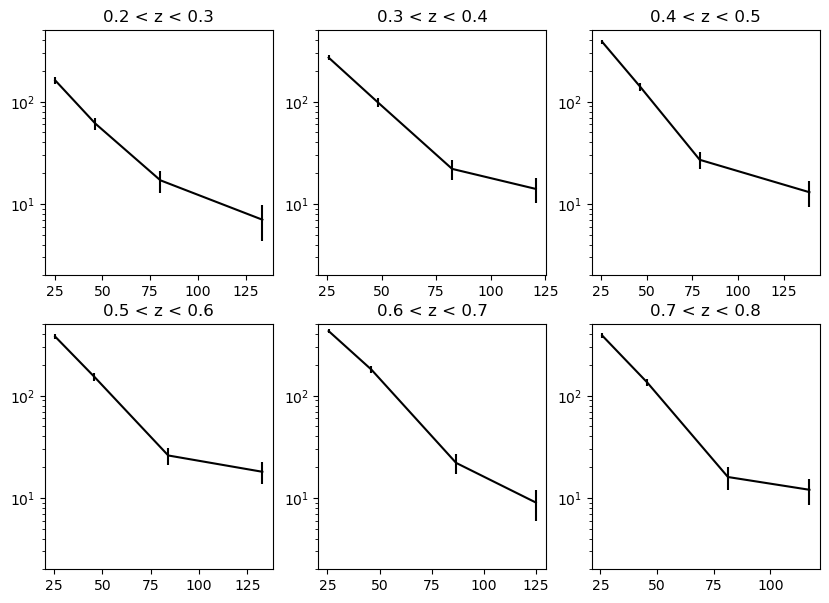

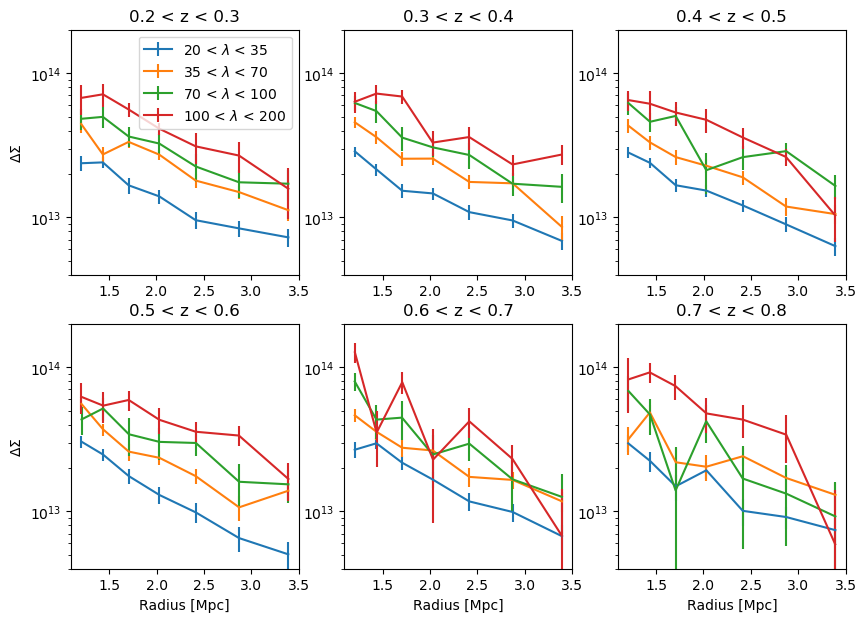

In [4]:
plt.figure(figsize=(10, 7))
counts_capish = np.zeros((len(Z_bin), len(Obs_bin)))
counts_capish_cov = np.zeros((len(Z_bin), len(Obs_bin), len(Z_bin), len(Obs_bin)))

for i, z_bin in enumerate(Z_bin):

    plt.subplot(231+i)
    plt.title(f'{z_bin[0]:.1f} < z < {z_bin[1]:.1f}')
    plt.ylim(2,500)
    plt.yscale('log')

    x = []
    y = []
    for j, rich_bin in enumerate(Obs_bin):

        mask = (lensing_profiles['cluster_redshift'] > z_bin[0])*(lensing_profiles['cluster_redshift'] <= z_bin[1])
        mask *= (lensing_profiles['cluster_richness'] > rich_bin[0])*(lensing_profiles['cluster_richness'] <= rich_bin[1])
        x.append(np.mean(lensing_profiles['cluster_richness'][mask]))
        y.append(np.sum(mask))
        counts_capish[i, j] = np.sum(mask)
        counts_capish_cov[i, j, i, j] = np.sum(mask)
    plt.errorbar(x, y, np.sqrt(np.array(y)), color= 'k')


lensing_capish = np.zeros((len(Z_bin), len(Obs_bin), 7))
lensing_capish_cov = np.zeros((len(Z_bin), len(Obs_bin), 7, 7))

plt.figure(figsize=(10, 7))
for i, z_bin in enumerate(Z_bin):

    plt.subplot(231+i)
    plt.title(f'{z_bin[0]:.1f} < z < {z_bin[1]:.1f}')
    plt.yscale('log')
    plt.ylim(4e12, 2e14)
    if i >= 3:
        plt.xlabel('Radius [Mpc]')
    if i == 0 or i == 3:
        plt.ylabel(r'$\Delta\Sigma$')
    
    for j, rich_bin in enumerate(Obs_bin):

        mask = (lensing_profiles['cluster_redshift'] > z_bin[0])*(lensing_profiles['cluster_redshift'] <= z_bin[1])
        mask *= (lensing_profiles['cluster_richness'] > rich_bin[0])*(lensing_profiles['cluster_richness'] <= rich_bin[1])
        lensing_profiles_bin = lensing_profiles[mask]
        x_mean = np.mean(lensing_profiles_bin['binned_radius_Mpc'],axis=0)
        y_mean = np.average(lensing_profiles_bin['binned_profiles'], weights=lensing_profiles_bin['binned_weights'], axis=0)
        y_err_mean = np.std(lensing_profiles_bin['binned_profiles'], axis=0)/np.sqrt(np.sum(mask))
        lensing_capish[i, j] = y_mean
        lensing_capish_cov[i, j] = np.diag(y_err_mean**2)
        plt.errorbar(x_mean, y_mean, y_err_mean, label = f'{rich_bin[0]:.0f} < $\lambda$ < {rich_bin[1]:.0f}')
        if i==0: 
                plt.legend()

## Save to SACC

In [5]:
import numpy as np
import sacc
from scipy.linalg import block_diag

Radius_bins = lensing_profiles["binned_radius_Mpc"][0]
survey_name = "capish_dc2"
area = 440.0   # change if needed


s = sacc.Sacc()


# -------------------------
# Add tracers
# -------------------------

for i, zbin in enumerate(Z_bin):
    s.add_tracer(
        "bin_z",
        f"bin_z_{i}",
        zbin[0],
        zbin[1],
    )

for j, rbin in enumerate(Obs_bin):
    # same convention as your pipeline: richness stored in log10
    s.add_tracer(
        "bin_richness",
        f"bin_rich_{j}",
        np.log10(rbin[0]),
        np.log10(rbin[1]),
    )

for k, radius in enumerate(Radius_bins):

    s.add_tracer(
        "bin_radius",
        f"radius_{k}",
        radius,        # lower
        radius,
        radius,        # upper
        metadata={"bin_units": "Mpc",
                 "center": radius}
    )

s.add_tracer(
    "survey",
    survey_name,
    area
)


# -------------------------
# Add counts
# -------------------------

for i in range(len(Z_bin)):
    for j in range(len(Obs_bin)):

        s.add_data_point(
            sacc.standard_types.cluster_counts,
            (
                survey_name,
                f"bin_rich_{j}",
                f"bin_z_{i}"
            ),
            counts_capish[i,j]
        )


# -------------------------
# Add Delta Sigma
# -------------------------

for i in range(len(Z_bin)):
    for j in range(len(Obs_bin)):
        for k in range(len(Radius_bins)):

            s.add_data_point(
                sacc.standard_types.cluster_delta_sigma,
                (
                    survey_name,
                    f"bin_rich_{j}",
                    f"bin_z_{i}",
                    f"radius_{k}"
                ),
                lensing_capish[i,j,k]
            )


# -------------------------
# Add covariance
# -------------------------

# Counts covariance
counts_cov_matrix = counts_capish_cov.reshape(
    len(Z_bin)*len(Obs_bin),
    len(Z_bin)*len(Obs_bin)
)


# DS covariance blocks
ds_blocks = []

for i in range(len(Z_bin)):
    for j in range(len(Obs_bin)):
        ds_blocks.append(
            lensing_capish_cov[i,j]
        )


full_cov = block_diag(
    counts_cov_matrix,
    *ds_blocks
)


s.add_covariance(full_cov)


# canonical order and save
s.to_canonical_order()

s.save_fits(
    "./mock_DC2like_cluster_sacc.sacc",
    overwrite=True
)

print("Saved mock_DC2like_cluster_sacc.sacc")
print("Number of data points:", len(s.data))
print("Covariance shape:", full_cov.shape)

Saved mock_DC2like_cluster_sacc.sacc
Number of data points: 192
Covariance shape: (192, 192)


## Data versus Fiducial Prediction Comparison

## Loading Data from SACC

In [6]:

# Load SACC catalog
sacc_file = sacc.Sacc.load_fits("./run_in2p3_both/outputs_both/clusters_sacc_file_cov.sacc")

rich_bin_label = ["20-35", "35-70", "70-100", "100-200"]
z_bin_label = ["0.2-0.3", "0.3-0.4", "0.4-0.5", "0.5-0.6", "0.6-0.7", "0.7-0.8"]

# Extract redshift bins from tracers
Z_bins = []
z_keys = sorted([k for k in sacc_file.tracers.keys() if 'bin_z' in k])
for k in z_keys:
    tracer = sacc_file.tracers[k]
    Z_bins.append([tracer.lower, tracer.upper])
Z_bins = np.array(Z_bins)

# Extract richness bins
Rich_bins = []
r_keys = sorted([k for k in sacc_file.tracers.keys() if 'bin_rich' in k])
for k in r_keys:
    tracer = sacc_file.tracers[k]
    Rich_bins.append([tracer.lower, tracer.upper])
Rich_bins = np.array(Rich_bins)

# Extract radius bin centers
Radius_bins = []
radius_keys = sorted([k for k in sacc_file.tracers.keys() if 'radius' in k])
for k in radius_keys:
    tracer = sacc_file.tracers[k]
    Radius_bins.append(tracer.center)
Radius_bins = np.array(Radius_bins)

print("Redshift bins:", Z_bins)
print("Richness bins:", Rich_bins)
print("Radius centers:", Radius_bins)


n_z = len(Z_bins)
n_r = len(Rich_bins)

counts_data = np.zeros((n_z, n_r))

for z_idx in range(n_z):
    for r_idx in range(n_r):
        trac_counts = ('capish_dc2',
                       f'bin_rich_{r_idx}',
                       f'bin_z_{z_idx}')

        val_counts = sacc_file.get_data_points(
            sacc.data_types.standard_types.cluster_counts,
            trac_counts
        )[0].value

        counts_data[z_idx, r_idx] = val_counts

print("Counts from SACC:")
print(counts_data)

n_z = len(Z_bins)
n_r = len(Rich_bins)
n_rad = len(Radius_bins)

shear_data = np.zeros((n_z, n_r, n_rad))

for i in range(n_z):
    for j in range(n_r):
        for k in range(n_rad):

            trac = (
                'capish_dc2',
                f'bin_rich_{j}',
                f'bin_z_{i}',
                f'radius_{k}'
            )

            val = sacc_file.get_data_points(
                sacc.data_types.standard_types.cluster_delta_sigma,
                trac
            )[0].value

            shear_data[i, j, k] = val

print("Shear data shape:", shear_data.shape)
print(radius_keys)
print(Radius_bins)


Redshift bins: [[0.2 0.3]
 [0.3 0.4]
 [0.4 0.5]
 [0.5 0.6]
 [0.6 0.7]
 [0.7 0.8]]
Richness bins: [[1.30103    1.54406804]
 [1.54406804 1.84509804]
 [1.84509804 2.        ]
 [2.         2.30103   ]]
Radius centers: [1.2057981  1.44106638 1.70653036 2.0323541  2.42048101 2.87269061
 3.39840574]
Counts from SACC:
[[162.  61.  17.   7.]
 [270.  99.  22.  14.]
 [385. 140.  27.  13.]
 [379. 153.  26.  18.]
 [429. 180.  22.   9.]
 [388. 135.  16.  12.]]
Shear data shape: (6, 4, 7)
[np.str_('radius_0'), np.str_('radius_1'), np.str_('radius_2'), np.str_('radius_3'), np.str_('radius_4'), np.str_('radius_5'), np.str_('radius_6')]
[1.2057981  1.44106638 1.70653036 2.0323541  2.42048101 2.87269061
 3.39840574]


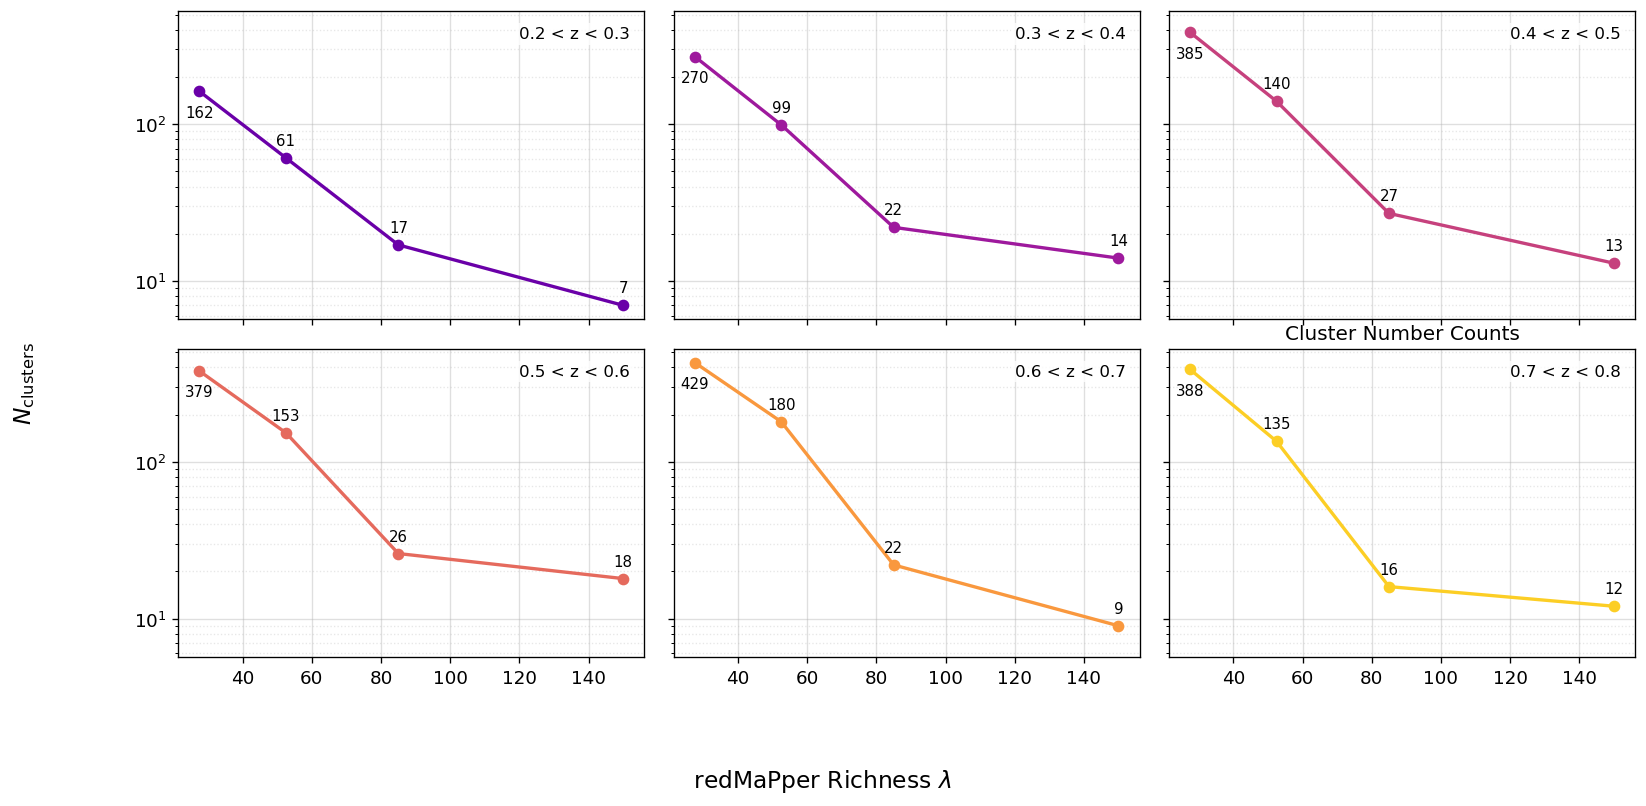

Total Clusters: 2984.0


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Compute richness bin centers ----------
rich_centers = 0.5 * (10**Rich_bins[:, 0] + 10**Rich_bins[:, 1])

# ---------- Use data-driven dimensions ----------
n_z = counts_data.shape[0]
n_r = counts_data.shape[1]

# Redshift labels (USE THESE, not Z_bins)
z_bin_label = ["0.2 < z < 0.3", "0.3 < z < 0.4", "0.4 < z < 0.5",
               "0.5 < z < 0.6", "0.6 < z < 0.7", "0.7 < z < 0.8"]

# ---------- Global style ----------
plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 13,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 120
})

# ---------- Layout ----------
ncols = 3
nrows = int(np.ceil(n_z / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 7), sharex=True, sharey=True)
axes = axes.flatten()

# ---------- Colors ----------
colors = plt.cm.plasma(np.linspace(0.2, 0.9, n_z))  # nicer than viridis for contrast

# ---------- Plot loop ----------
for i in range(n_z):
    ax = axes[i]

    y = counts_data[i, :]

    ax.plot(
        rich_centers,
        y,
        marker='o',
        linestyle='-',
        linewidth=2,
        markersize=6,
        color=colors[i]
    )

    # ---------- Annotate each point ----------
    ymax = np.max(y)
    
    for x, val in zip(rich_centers, y):
        if val > 0:
            # If close to top → place label BELOW
            if val > 0.7 * ymax:
                offset = (0, -8)
                va = 'top'
            else:
                offset = (0, 6)
                va = 'bottom'
    
            ax.annotate(
                f"{int(val)}",
                (x, val),
                textcoords="offset points",
                xytext=offset,
                ha='center',
                va=va,
                fontsize=9
            )

    # ---------- Log scale ----------
    ax.set_yscale("log")

    # ---------- Grid ----------
    ax.grid(True, which='major', linestyle='-', alpha=0.4)
    ax.grid(True, which='minor', linestyle=':', alpha=0.3)

    # ---------- Panel label ----------
    ax.text(
        0.97, 0.95,
        z_bin_label[i],
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2)
    )

# ---------- Hide unused panels ----------
for j in range(n_z, len(axes)):
    axes[j].axis('off')

# ---------- Shared labels ----------
fig.supxlabel(r" redMaPper Richness $\lambda$", fontsize=14)
fig.supylabel(r"$N_{\mathrm{clusters}}$", fontsize=14)

# ---------- Layout ----------
plt.tight_layout(rect=[0.05, 0.05, 1, 0.97])
plt.title("Cluster Number Counts")
# ---------- Save ----------

plt.show()

print(f"Total Clusters: {np.sum(counts_data.flatten())}")

## Prediction fiducial

In [8]:
from crow import ClusterShearProfile
from crow import ClusterAbundance
from crow.recipes.binned_exact import ExactBinnedClusterRecipe
from crow.recipes.binned_grid import GridBinnedClusterRecipe
from crow import completeness_models, mass_proxy, purity_models, kernel
from crow.properties import ClusterProperty


mass_richness_unb = mass_proxy.MurataUnbinned(pivot_log_mass=14.3, pivot_redshift=0.5)
mass_richness_unb.parameters["mu0"] = 3.34
mass_richness_unb.parameters["mu1"] = 2.3/np.log(10)
mass_richness_unb.parameters["mu2"] = 0.0
mass_richness_unb.parameters["sigma0"] = 0.56
mass_richness_unb.parameters["sigma1"] =0.0
mass_richness_unb.parameters["sigma2"] = 0.0


hmf = ccl.halos.MassFuncDespali16(mass_def="200c")
cosmo = ccl.Cosmology(
    Omega_c=0.1109 / 0.71**2,
    Omega_b=0.02258 / 0.71**2,
    h=0.71,
    n_s=0.963,
    sigma8=0.8,
    w0=-1.0,
    wa=0.0,
    transfer_function="boltzmann_camb"
)

mass_grid_size = 200
redshift_grid_size = 40
proxy_grid_size = 40
sky_area =  440.78987
mass_interval = (12.0, 15.5)


cl_abundandce = ClusterAbundance(cosmo, hmf)
cl_delta_sigma = ClusterShearProfile(
    cosmo, hmf, is_delta_sigma=True, cluster_concentration=3.8
)
redshift_distribution = kernel.SpectroscopicRedshift()


In [9]:
recipe_grid_abundance = GridBinnedClusterRecipe(
    mass_interval=mass_interval,
    cluster_theory=cl_abundandce,
    redshift_distribution=redshift_distribution,
    mass_distribution=mass_richness_unb,
    proxy_grid_size=proxy_grid_size,
    redshift_grid_size=redshift_grid_size,
    mass_grid_size=mass_grid_size,
    purity=None,
    completeness=None
)

recipe_grid_shear = GridBinnedClusterRecipe(
    mass_interval=mass_interval,
    cluster_theory=cl_delta_sigma,
    redshift_distribution=redshift_distribution,
    mass_distribution=mass_richness_unb,
    proxy_grid_size=proxy_grid_size,
    redshift_grid_size=redshift_grid_size,
    mass_grid_size=mass_grid_size,
    purity=None,
    completeness=None
)

recipe_grid_abundance.setup()
recipe_grid_shear.setup()

grid_counts_vals  = np.zeros((len(Z_bins), len(Rich_bins)))
grid_shear_vals  = np.zeros((len(Z_bins), len(Rich_bins), len(Radius_bins)))
grid_shear_error  = np.zeros((len(Z_bins), len(Rich_bins), len(Radius_bins)))
for i, zb in enumerate(Z_bins):
    for j, pb in enumerate(Rich_bins):
        print(f"Redshift x Log10 Richness bins: {zb, pb}")
        val_counts = recipe_grid_abundance.evaluate_theory_prediction_counts(np.array(zb), np.array(pb), sky_area)
        grid_counts_vals[i,j] = val_counts
        shear_vals = recipe_grid_shear.evaluate_theory_prediction_lensing_profile(np.array(zb), np.array(pb), np.array(Radius_bins), sky_area, ClusterProperty.DELTASIGMA) / val_counts
        grid_shear_vals[i,j, :] = shear_vals
        grid_shear_error[i, j, :] = abs(1.0 - shear_vals / shear_data[i, j, :])

rel_error_matrix = np.abs(1 - grid_counts_vals / counts_data)

n_i, n_j = rel_error_matrix.shape


print(f"Theoretical Counts: {grid_counts_vals}")

Redshift x Log10 Richness bins: (array([0.2, 0.3]), array([1.30103   , 1.54406804]))
Redshift x Log10 Richness bins: (array([0.2, 0.3]), array([1.54406804, 1.84509804]))
Redshift x Log10 Richness bins: (array([0.2, 0.3]), array([1.84509804, 2.        ]))
Redshift x Log10 Richness bins: (array([0.2, 0.3]), array([2.     , 2.30103]))
Redshift x Log10 Richness bins: (array([0.3, 0.4]), array([1.30103   , 1.54406804]))
Redshift x Log10 Richness bins: (array([0.3, 0.4]), array([1.54406804, 1.84509804]))
Redshift x Log10 Richness bins: (array([0.3, 0.4]), array([1.84509804, 2.        ]))
Redshift x Log10 Richness bins: (array([0.3, 0.4]), array([2.     , 2.30103]))
Redshift x Log10 Richness bins: (array([0.4, 0.5]), array([1.30103   , 1.54406804]))
Redshift x Log10 Richness bins: (array([0.4, 0.5]), array([1.54406804, 1.84509804]))
Redshift x Log10 Richness bins: (array([0.4, 0.5]), array([1.84509804, 2.        ]))
Redshift x Log10 Richness bins: (array([0.4, 0.5]), array([2.     , 2.30103])

## Best Fit Cosmo

In [10]:
### from crow import ClusterShearProfile
from crow import ClusterAbundance
from crow.recipes.binned_exact import ExactBinnedClusterRecipe
from crow.recipes.binned_grid import GridBinnedClusterRecipe
from crow import completeness_models, mass_proxy, purity_models, kernel
from crow.properties import ClusterProperty


mass_richness_unb_fit = mass_proxy.MurataUnbinned(pivot_log_mass=14.3, pivot_redshift=0.5)
mass_richness_unb_fit.parameters["mu0"] = 3.43
mass_richness_unb_fit.parameters["mu1"] =0.989
mass_richness_unb_fit.parameters["mu2"] = -0.17
mass_richness_unb_fit.parameters["sigma0"] =  0.467
mass_richness_unb_fit.parameters["sigma1"] =0.012
mass_richness_unb_fit.parameters["sigma2"] = 0.05



hmf = ccl.halos.MassFuncDespali16(mass_def="200c")
cosmo_fit = ccl.Cosmology(
    Omega_c=0.210,
    Omega_b=0.02258 / 0.71**2,
    h=0.71,
    n_s=0.963,
    sigma8=0.813,
    w0=-1.0,
    wa=0.0,
    transfer_function="boltzmann_camb"
)

mass_grid_size = 200
redshift_grid_size = 40
proxy_grid_size = 40
sky_area =  440.78987
mass_interval = (12.0, 15.5)


cl_abundandce = ClusterAbundance(cosmo_fit, hmf)
cl_delta_sigma = ClusterShearProfile(
    cosmo_fit, hmf, is_delta_sigma=True, cluster_concentration=3.8
)
redshift_distribution = kernel.SpectroscopicRedshift()


In [11]:
recipe_grid_abundance = GridBinnedClusterRecipe(
    mass_interval=mass_interval,
    cluster_theory=cl_abundandce,
    redshift_distribution=redshift_distribution,
    mass_distribution=mass_richness_unb_fit,
    proxy_grid_size=proxy_grid_size,
    redshift_grid_size=redshift_grid_size,
    mass_grid_size=mass_grid_size,
    purity=None,
    completeness=None
)

recipe_grid_shear = GridBinnedClusterRecipe(
    mass_interval=mass_interval,
    cluster_theory=cl_delta_sigma,
    redshift_distribution=redshift_distribution,
    mass_distribution=mass_richness_unb_fit,
    proxy_grid_size=proxy_grid_size,
    redshift_grid_size=redshift_grid_size,
    mass_grid_size=mass_grid_size,
    purity=None,
    completeness=None
)

recipe_grid_abundance.setup()
recipe_grid_shear.setup()

grid_counts_vals_fit  = np.zeros((len(Z_bins), len(Rich_bins)))
grid_shear_vals_fit  = np.zeros((len(Z_bins), len(Rich_bins), len(Radius_bins)))
grid_shear_error_fit  = np.zeros((len(Z_bins), len(Rich_bins), len(Radius_bins)))
for i, zb in enumerate(Z_bins):
    for j, pb in enumerate(Rich_bins):
        print(f"Redshift x Log10 Richness bins: {zb, pb}")
        val_counts = recipe_grid_abundance.evaluate_theory_prediction_counts(np.array(zb), np.array(pb), sky_area)
        grid_counts_vals_fit[i,j] = val_counts
        shear_vals = recipe_grid_shear.evaluate_theory_prediction_lensing_profile(np.array(zb), np.array(pb), np.array(Radius_bins), sky_area, ClusterProperty.DELTASIGMA) / val_counts
        grid_shear_vals_fit[i,j, :] = shear_vals
        grid_shear_error_fit[i, j, :] = abs(1.0 - shear_vals / shear_data[i, j, :])

rel_error_matrix_fit = np.abs(1 - grid_counts_vals_fit / counts_data)

n_i, n_j = rel_error_matrix_fit.shape


print(f"Theoretical Counts: {grid_counts_vals_fit}")

Redshift x Log10 Richness bins: (array([0.2, 0.3]), array([1.30103   , 1.54406804]))
Redshift x Log10 Richness bins: (array([0.2, 0.3]), array([1.54406804, 1.84509804]))
Redshift x Log10 Richness bins: (array([0.2, 0.3]), array([1.84509804, 2.        ]))
Redshift x Log10 Richness bins: (array([0.2, 0.3]), array([2.     , 2.30103]))
Redshift x Log10 Richness bins: (array([0.3, 0.4]), array([1.30103   , 1.54406804]))
Redshift x Log10 Richness bins: (array([0.3, 0.4]), array([1.54406804, 1.84509804]))
Redshift x Log10 Richness bins: (array([0.3, 0.4]), array([1.84509804, 2.        ]))
Redshift x Log10 Richness bins: (array([0.3, 0.4]), array([2.     , 2.30103]))
Redshift x Log10 Richness bins: (array([0.4, 0.5]), array([1.30103   , 1.54406804]))
Redshift x Log10 Richness bins: (array([0.4, 0.5]), array([1.54406804, 1.84509804]))
Redshift x Log10 Richness bins: (array([0.4, 0.5]), array([1.84509804, 2.        ]))
Redshift x Log10 Richness bins: (array([0.4, 0.5]), array([2.     , 2.30103])

## Final plots

In [12]:
# ------------------------------------------------------------
# Errors from SACC covariance
# ------------------------------------------------------------
cov = sacc_file.covariance.covmat
counts_err = np.zeros_like(counts_data)
shear_err = np.zeros_like(shear_data)

for i in range(n_z):
    for j in range(n_r):

        trac_counts = (
            "capish_dc2",
            f"bin_rich_{j}",
            f"bin_z_{i}",
        )

        ind = sacc_file.indices(
            sacc.data_types.standard_types.cluster_counts,
            tracers=trac_counts,
        )
        counts_err[i, j] = np.sqrt(cov[ind[0], ind[0]])

        for k in range(n_rad):

            trac_shear = (
                "capish_dc2",
                f"bin_rich_{j}",
                f"bin_z_{i}",
                f"radius_{k}",
            )

            ind = sacc_file.indices(
                sacc.data_types.standard_types.cluster_delta_sigma,
                tracers=trac_shear,
            )

            shear_err[i, j, k] = np.sqrt(cov[ind[0], ind[0]])

[0]
[6]
[12]
[18]
[1]
[7]
[13]
[19]
[2]
[8]
[14]
[20]
[3]
[9]
[15]
[21]
[4]
[10]
[16]
[22]
[5]
[11]
[17]
[23]


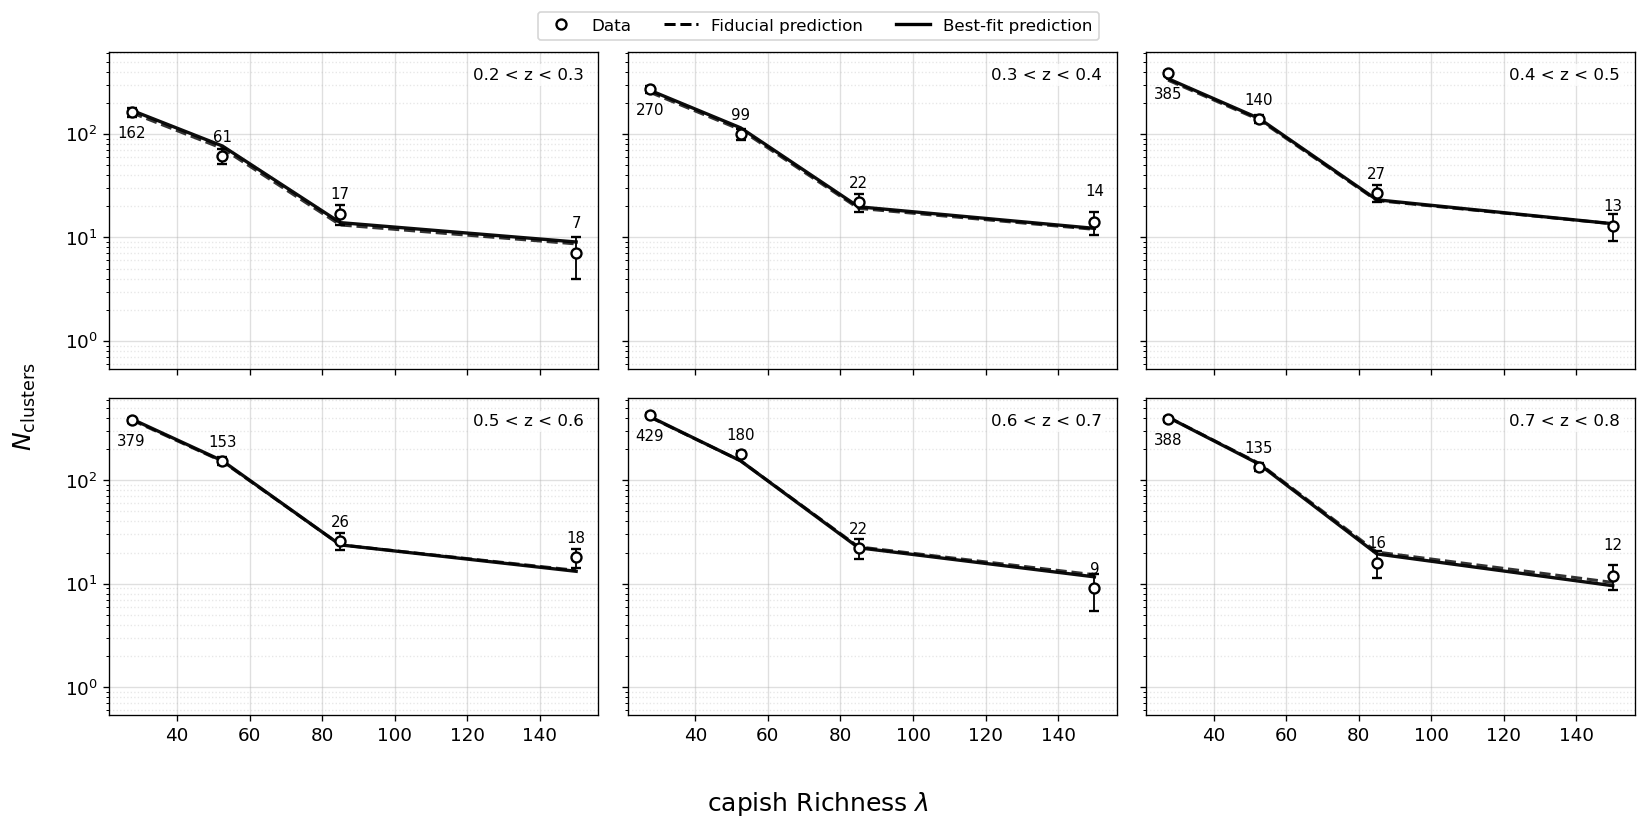

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------- Compute richness bin centers ----------
rich_centers = 0.5 * (10**Rich_bins[:, 0] + 10**Rich_bins[:, 1])

# ---------- Use data-driven dimensions ----------
n_z = counts_data.shape[0]
n_r = counts_data.shape[1]

z_bin_label = [
    "0.2 < z < 0.3",
    "0.3 < z < 0.4",
    "0.4 < z < 0.5",
    "0.5 < z < 0.6",
    "0.6 < z < 0.7",
    "0.7 < z < 0.8",
]

# ---------- Global style ----------
plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 13,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 120,
})

# ---------- Layout ----------
ncols = 3
nrows = int(np.ceil(n_z / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 7), sharex=True, sharey=True)
axes = axes.flatten()


# ---------- Plot loop ----------
for i in range(n_z):
    ax = axes[i]
    color = "black"
    y = counts_data[i, :]

    # Data: open circles only
    ax.errorbar(
        rich_centers,
        counts_data[i, :],
        yerr=counts_err[i, :],
        fmt="o",
        color=color,
        markerfacecolor="white",
        markeredgecolor=color,
        markeredgewidth=1.4,
        markersize=6,
        capsize=3,
        elinewidth=1.1,
        linestyle="none",
        zorder=4,
    )

    # Fiducial prediction: dashed
    ax.plot(
        rich_centers,
        grid_counts_vals[i, :],
        linestyle="--",
        linewidth=1.8,
        color=color,
        alpha=0.8,
        zorder=2,
    )

    # Best-fit prediction: solid
    ax.plot(
        rich_centers,
        grid_counts_vals_fit[i, :],
        linestyle="-",
        linewidth=2.0,
        color=color,
        alpha=0.95,
        zorder=3,
    )

    # ---------- Annotate data points ----------
    ymax = np.max(y)

    special_z_bins = {0, 1, 5}
    
    # Last richness bin
    last_richness_bin = len(rich_centers) - 1
    
    for k, (x, val) in enumerate(zip(rich_centers, y)):
        if val > 0:
    
            # Special case: only last richness point in redshift bins 1, 2, and 6
            if (i in special_z_bins) and (k == last_richness_bin):
                offset = (0, 14)   # move upward
                va = "bottom"
    
            # Default behavior
            elif val > 0.7 * ymax:
                offset = (0, -8)
                va = "top"
            else:
                offset = (0, 7)
                va = "bottom"
    
            ax.annotate(
                f"{int(val)}",
                (x, val),
                textcoords="offset points",
                xytext=offset,
                ha="center",
                va=va,
                fontsize=9,
            )

    ax.set_yscale("log")

    ax.grid(True, which="major", linestyle="-", alpha=0.4)
    ax.grid(True, which="minor", linestyle=":", alpha=0.3)

    ax.text(
        0.97,
        0.95,
        z_bin_label[i],
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2),
    )

# ---------- Hide unused panels ----------
for j in range(n_z, len(axes)):
    axes[j].axis("off")

# ---------- Shared labels ----------
fig.supxlabel(rf"capish Richness $\lambda$", fontsize=15)
fig.supylabel(r"$N_{\mathrm{clusters}}$", fontsize=15)

# ---------- Legend ----------
style_handles = [
    Line2D(
        [0], [0],
        color="black",
        marker="o",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.4,
        linestyle="none",
        markersize=6,
        label="Data",
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle="--",
        lw=1.8,
        label="Fiducial prediction",
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle="-",
        lw=2.0,
        label="Best-fit prediction",
    ),
]

fig.legend(
    handles=style_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=3,
    fontsize=10,
    frameon=True,
)

plt.tight_layout(rect=[0.008, 0.008, 1, 0.95])
plt.savefig("./figures/counts_capish.pdf", dpi=300)
plt.show()

In [14]:
# chi^2 / N for data vs fiducial prediction
data = np.asarray(counts_data, dtype=float)
model = np.asarray(grid_counts_vals, dtype=float)
err = np.asarray(counts_err, dtype=float)

mask = np.isfinite(data) & np.isfinite(model) & np.isfinite(err) & (err > 0)

chi2 = np.sum(((data[mask] - model[mask]) / err[mask])**2)
N = np.sum(mask)

print(f"chi2 = {chi2:.3f}")
print(f"N = {N}")
print(f"chi2 / N = {chi2 / N:.3f}")

chi2 = 22.677
N = 24
chi2 / N = 0.945


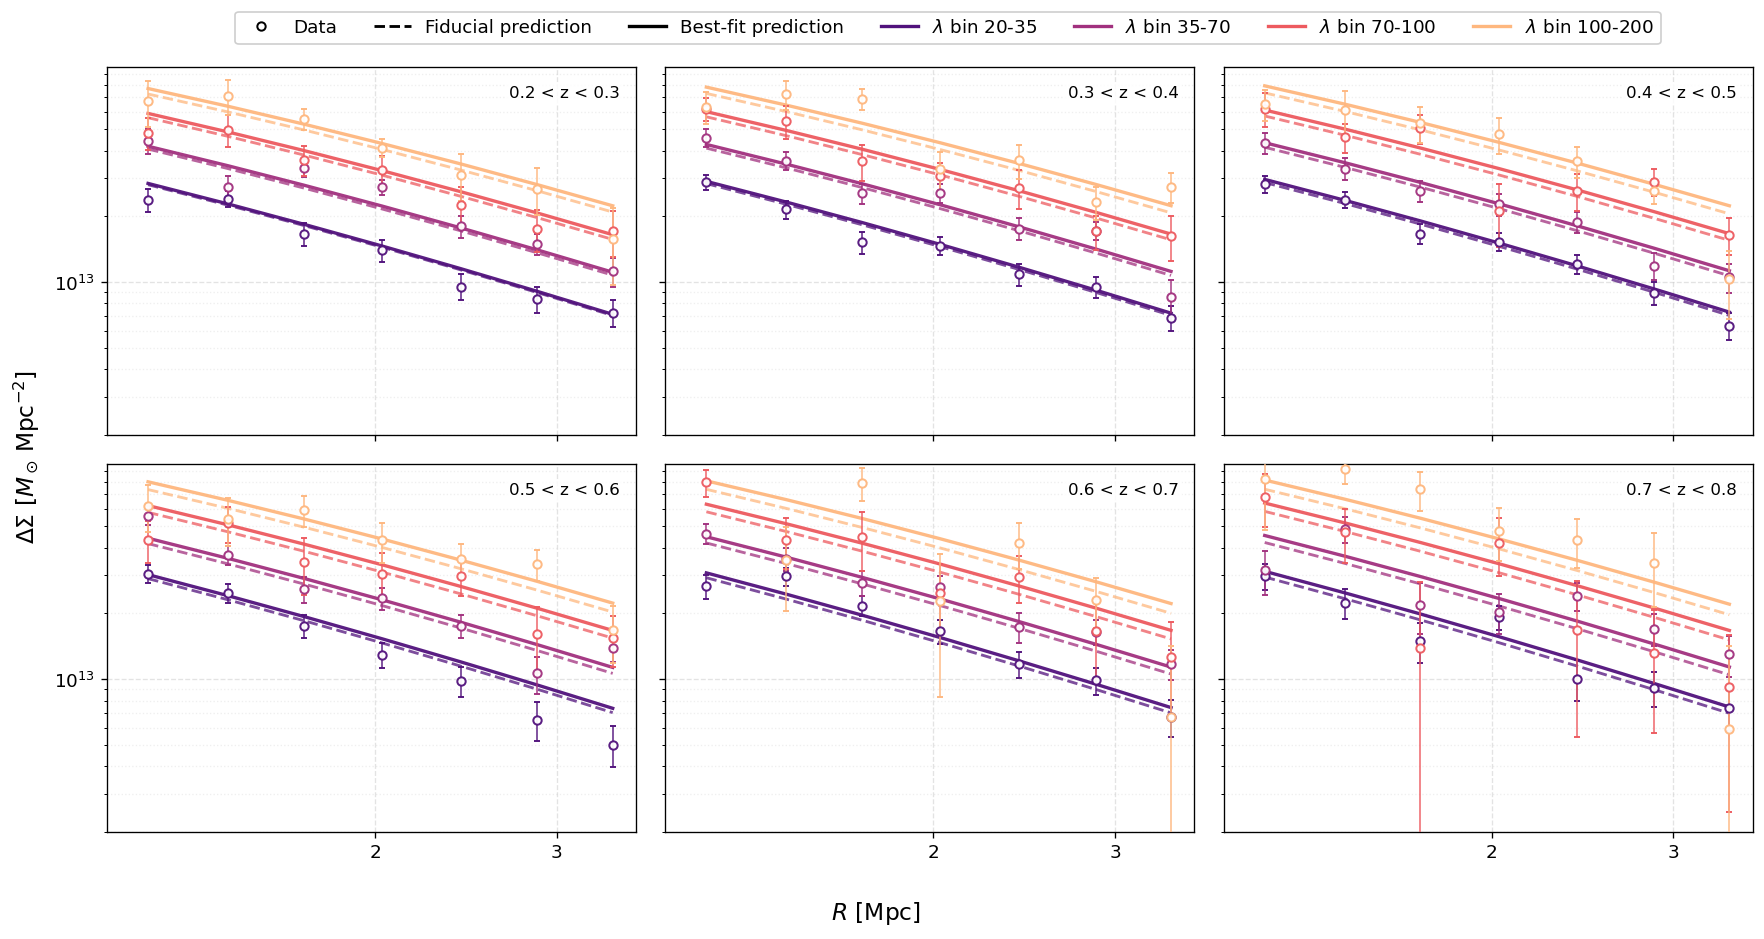

In [15]:
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

rich_colors = plt.cm.magma(np.linspace(0.25, 0.85, n_r))

ncols = 3
nrows = int(np.ceil(n_z / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(15, 8),
    sharex=True,
    sharey=True,
)

axes = axes.flatten()

for i in range(n_z):
    ax = axes[i]

    for j in range(n_r):
        color = rich_colors[j]

        # Data: points only + error bars
        ax.errorbar(
            Radius_bins,
            shear_data[i, j, :],
            yerr=shear_err[i, j, :],
            fmt="o",
            color=color,
            markerfacecolor="white",
            markeredgecolor=color,
            markeredgewidth=1.2,
            markersize=5,
            elinewidth=0.9,
            capsize=2,
            linestyle="none",
            alpha=0.95,
            zorder=5,
        )

        # Fiducial prediction: dashed line
        ax.plot(
            Radius_bins,
            grid_shear_vals[i, j, :],
            linestyle="--",
            color=color,
            linewidth=1.7,
            alpha=0.75,
            zorder=3,
        )

        # # Best-fit prediction: solid line
        ax.plot(
            Radius_bins,
            grid_shear_vals_fit[i, j, :],
            linestyle="-",
            color=color,
            linewidth=2.0,
            alpha=0.95,
            zorder=4,
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(left=1.1)
    ax.set_ylim(bottom=2e12)

    ax.grid(True, which="major", linestyle="--", alpha=0.35)
    ax.grid(True, which="minor", linestyle=":", alpha=0.2)

    ax.text(
        0.97,
        0.95,
        z_bin_label[i],
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", pad=2),
    )

    ax.xaxis.set_major_locator(mticker.FixedLocator([1, 2, 3, 4]))
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:g}"))

for j in range(n_z, len(axes)):
    axes[j].axis("off")

fig.supxlabel(r"$R\ [\mathrm{Mpc}]$", fontsize=14)
fig.supylabel(r"$\Delta\Sigma\ [M_\odot\,\mathrm{Mpc}^{-2}]$", fontsize=14)

style_handles = [
    Line2D(
        [0], [0],
        color="black",
        marker="o",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.2,
        linestyle="none",
        markersize=5,
        label="Data",
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle="--",
        lw=1.7,
        label="Fiducial prediction",
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle="-",
        lw=2.0,
        label="Best-fit prediction",
    ),
]

rich_handles = [
    Line2D(
        [0], [0],
        color=rich_colors[j],
        lw=2,
        label=rf"$\lambda$ bin {rich_bin_label[j]}",
    )
    for j in range(n_r)
]

fig.legend(
    handles=style_handles + rich_handles,
    loc="lower center",
    bbox_to_anchor=(0.54, 0.92),
    ncol=3 + n_r,
    fontsize=11,
    frameon=True,
    framealpha=0.95,
    edgecolor="0.8",
)

plt.tight_layout(rect=[0.0008, 0.001, 1, 0.93])
plt.savefig(
    "./figures/shear_capish.pdf",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.08,
)
plt.show()

In [16]:
# chi^2 / N for shear data vs fiducial prediction
data = np.asarray(shear_data, dtype=float)
model = np.asarray(grid_shear_vals, dtype=float)
err = np.asarray(shear_err, dtype=float)

mask = np.isfinite(data) & np.isfinite(model) & np.isfinite(err) & (err > 0)

chi2 = np.sum(((data[mask] - model[mask]) / err[mask])**2)
N = np.sum(mask)

print(f"chi2 = {chi2:.3f}")
print(f"N = {N}")
print(f"chi2 / N = {chi2 / N:.3f}")

chi2 = 194.249
N = 168
chi2 / N = 1.156


## Countour Plots

In [17]:
import sys
sys.path.append("../../")
from clpipeline.utils.cosmosis_mcmc_plots import plot_triangle, ChainStyle, PlotConfig, chains_to_fits, _load_cosmosis_chain

/sps/lsst/groups/clusters/cl_pipeline_project/conda_envs/firecrown_developer_clp/lib/python3.13/site-packages/ceci/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


LOADING CHAIN FROM FILE:  /sps/lsst/users/ebarroso/CLPipeline/examples/cosmodc2_redmapper/baseline/cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
  Counts + Lensing, redMaPPer cosmoDC2 Baseline: 60,200 samples  (/sps/lsst/users/ebarroso/CLPipeline/examples/cosmodc2_redmapper/baseline/cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt)
LOADING CHAIN FROM FILE:  ./run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
  Counts + Lensing, Capish+CLMM Mocks: 86,800 samples  (./run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt)

Saved to figures/capish_redmapper.pdf


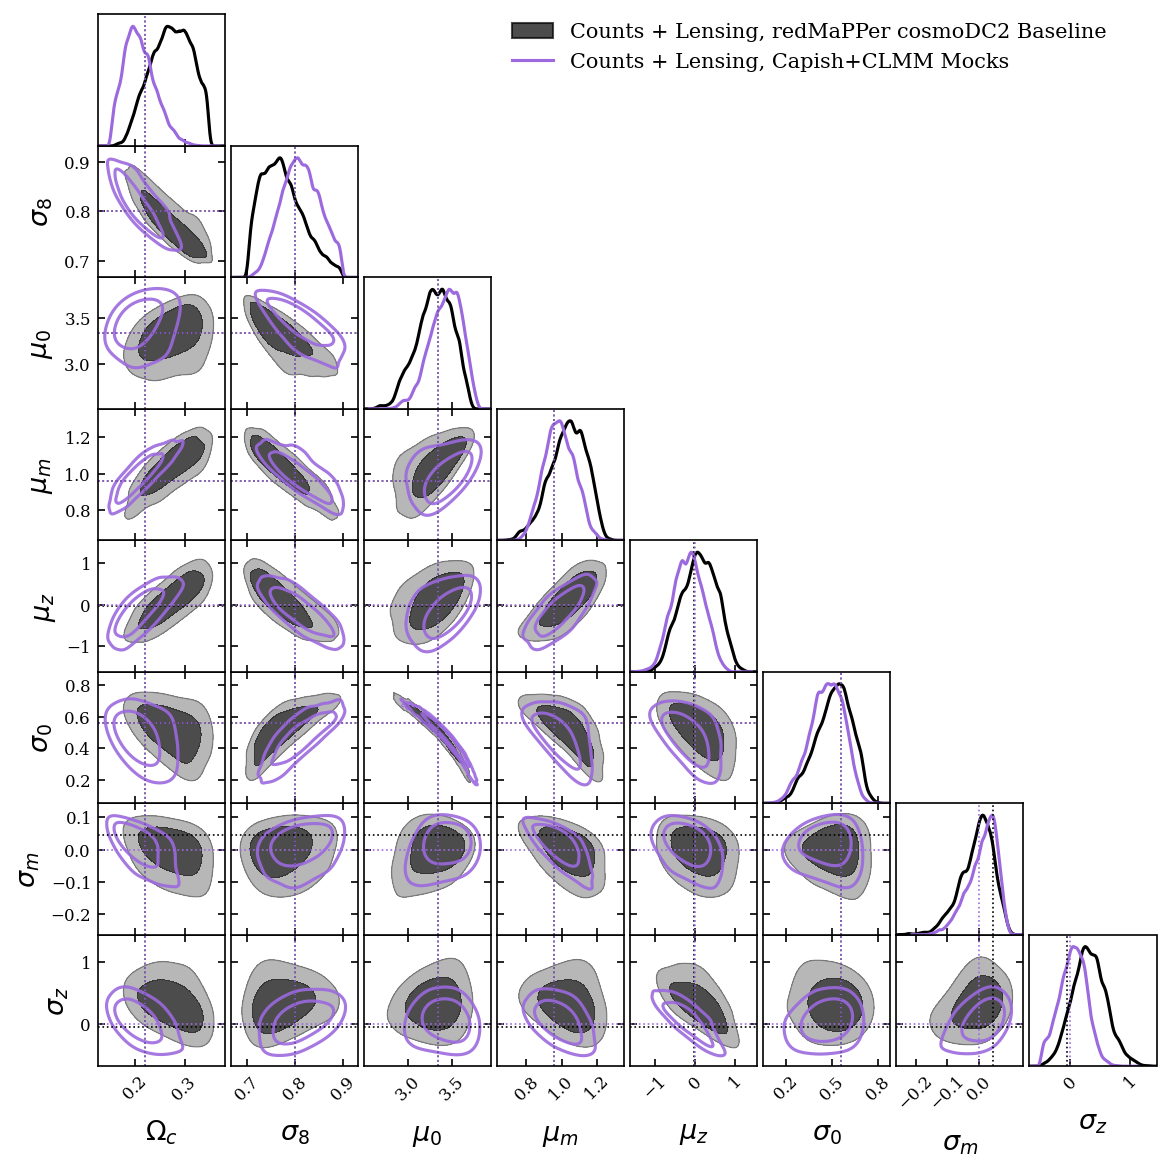


── Counts + Lensing, redMaPPer cosmoDC2 Baseline ──


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [18]:
import sys
sys.path.append("../../")
from clpipeline.utils.cosmosis_mcmc_plots import plot_triangle, ChainStyle, PlotConfig, chains_to_fits

DIR = ["/sps/lsst/users/ebarroso/CLPipeline/examples/cosmodc2_redmapper/baseline/cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt", "./run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"]



FIDUCIALS = [
        [
        (r"\Omega_c", 0.22),
        (r"\sigma_8", 0.80),
        (r"\mu_0", 3.34),
        (r"\mu_m", 0.958236982),
        (r"\mu_z", -0.0192802),
        (r"\sigma_0", 0.562317194),
        (r"\sigma_m", 0.04552506),
        (r"\sigma_z", -0.0445),
    ],
    [
        (r"\Omega_c", 0.22),
        (r"\sigma_8", 0.80),
        (r"\mu_0", 3.34),
        (r"\mu_m", 0.958236982),
        (r"\mu_z", 0.0),
        (r"\sigma_0", 0.56),
        (r"\sigma_m", 0.0),
        (r"\sigma_z", 0.0),
    ],
]

# STYLES_3 = [
#     ChainStyle("Counts + Lensing, Baseline", filled=True,  linestyle="-", fill_alpha=0.8, linewidth=1.6),
#     ChainStyle("Counts + Lensing, Capish Mocks", filled=True,  linestyle="-", fill_alpha=0.6, linewidth=1.2, color="#9C6ADE"),
# ]

STYLES_3 = [
    ChainStyle(
        "Counts + Lensing, redMaPPer cosmoDC2 Baseline",
        filled=True,
        fill_alpha=0.7,
        linewidth=1.5,
    ),
    ChainStyle(
        "Counts + Lensing, Capish+CLMM Mocks",
        filled=False,
        fill_alpha=0.5,
        linewidth=1.5,
        linestyle="-",
        color="#9C6ADE",
    ),
]

# ── Config ────────────────────────────────────────────────────────────────────
cfg_8par = PlotConfig(figsize=8, output_dir="./figures", burn_fraction=0.3)

# ── Plot ──────────────────────────────────────────────, save=False────────────────────────
samples_both = plot_triangle(DIR, FIDUCIALS, STYLES_3, name="capish_redmapper",  config=cfg_8par, save=True, multiple_fiducials=True)

# chains_to_fits(
#     samples    = [samples_both[1]],
#     params     = FIDUCIALS[1],
#     labels     = ["capish_chains_cc_wl"],
#     output_dir = "./chains/",
# )


In [19]:
import numpy as np
from astropy.io import fits

# Read saved Capish chain
filename = "./chains/capish_chains_cc_wl.fits"

with fits.open(filename) as hdul:
    data = hdul[1].data

# Get parameter names
print(data.columns.names)

fid = {
    "Omega_c": 0.22,
    "sigma_8": 0.80,
    "mu_0": 3.34,
    "mu_m": 0.99,
    "mu_z": 0.0,
    "sigma_0": 0.56,
    "sigma_m": 0.0,
    "sigma_z": 0.0,
}

# Compute posterior mean, std, and tension
for par, fid_value in fid.items():

    samples = data[par]

    mean = np.mean(samples)
    sigma = np.std(samples)

    tension = (mean - fid_value) / sigma

    print(
        f"{par:10s} "
        f"mean = {mean:.5f}, "
        f"sigma = {sigma:.5f}, "
        f"fid = {fid_value:.5f}, "
        f"tension = {tension:.2f} sigma"
    )

['Omega_c', 'sigma_8', 'mu_0', 'mu_m', 'mu_z', 'sigma_0', 'sigma_m', 'sigma_z']
Omega_c    mean = 0.20994, sigma = 0.03163, fid = 0.22000, tension = -0.32 sigma
sigma_8    mean = 0.81285, sigma = 0.03985, fid = 0.80000, tension = 0.32 sigma
mu_0       mean = 3.42797, sigma = 0.18023, fid = 3.34000, tension = 0.49 sigma
mu_m       mean = 0.98754, sigma = 0.08617, fid = 0.99000, tension = -0.03 sigma
mu_z       mean = -0.16907, sigma = 0.37670, fid = 0.00000, tension = -0.45 sigma
sigma_0    mean = 0.46681, sigma = 0.11051, fid = 0.56000, tension = -0.84 sigma
sigma_m    mean = 0.01167, sigma = 0.04638, fid = 0.00000, tension = 0.25 sigma
sigma_z    mean = 0.04921, sigma = 0.22593, fid = 0.00000, tension = 0.22 sigma


LOADING CHAIN FROM FILE:  /sps/lsst/users/ebarroso/CLPipeline/examples/cosmodc2_redmapper/baseline/cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  /sps/lsst/users/ebarroso/CLPipeline/examples/cosmodc2_redmapper/baseline/cosmodc2_redmapper_lensing/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  /sps/lsst/users/ebarroso/CLPipeline/examples/cosmodc2_redmapper/baseline/cosmodc2_redmapper_counts/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  /sps/lsst/users/ebarroso/CLPipeline/examples/cosmodc2_redmapper/baseline/cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in

Saved to figures/box_capish_vs_baseline.p

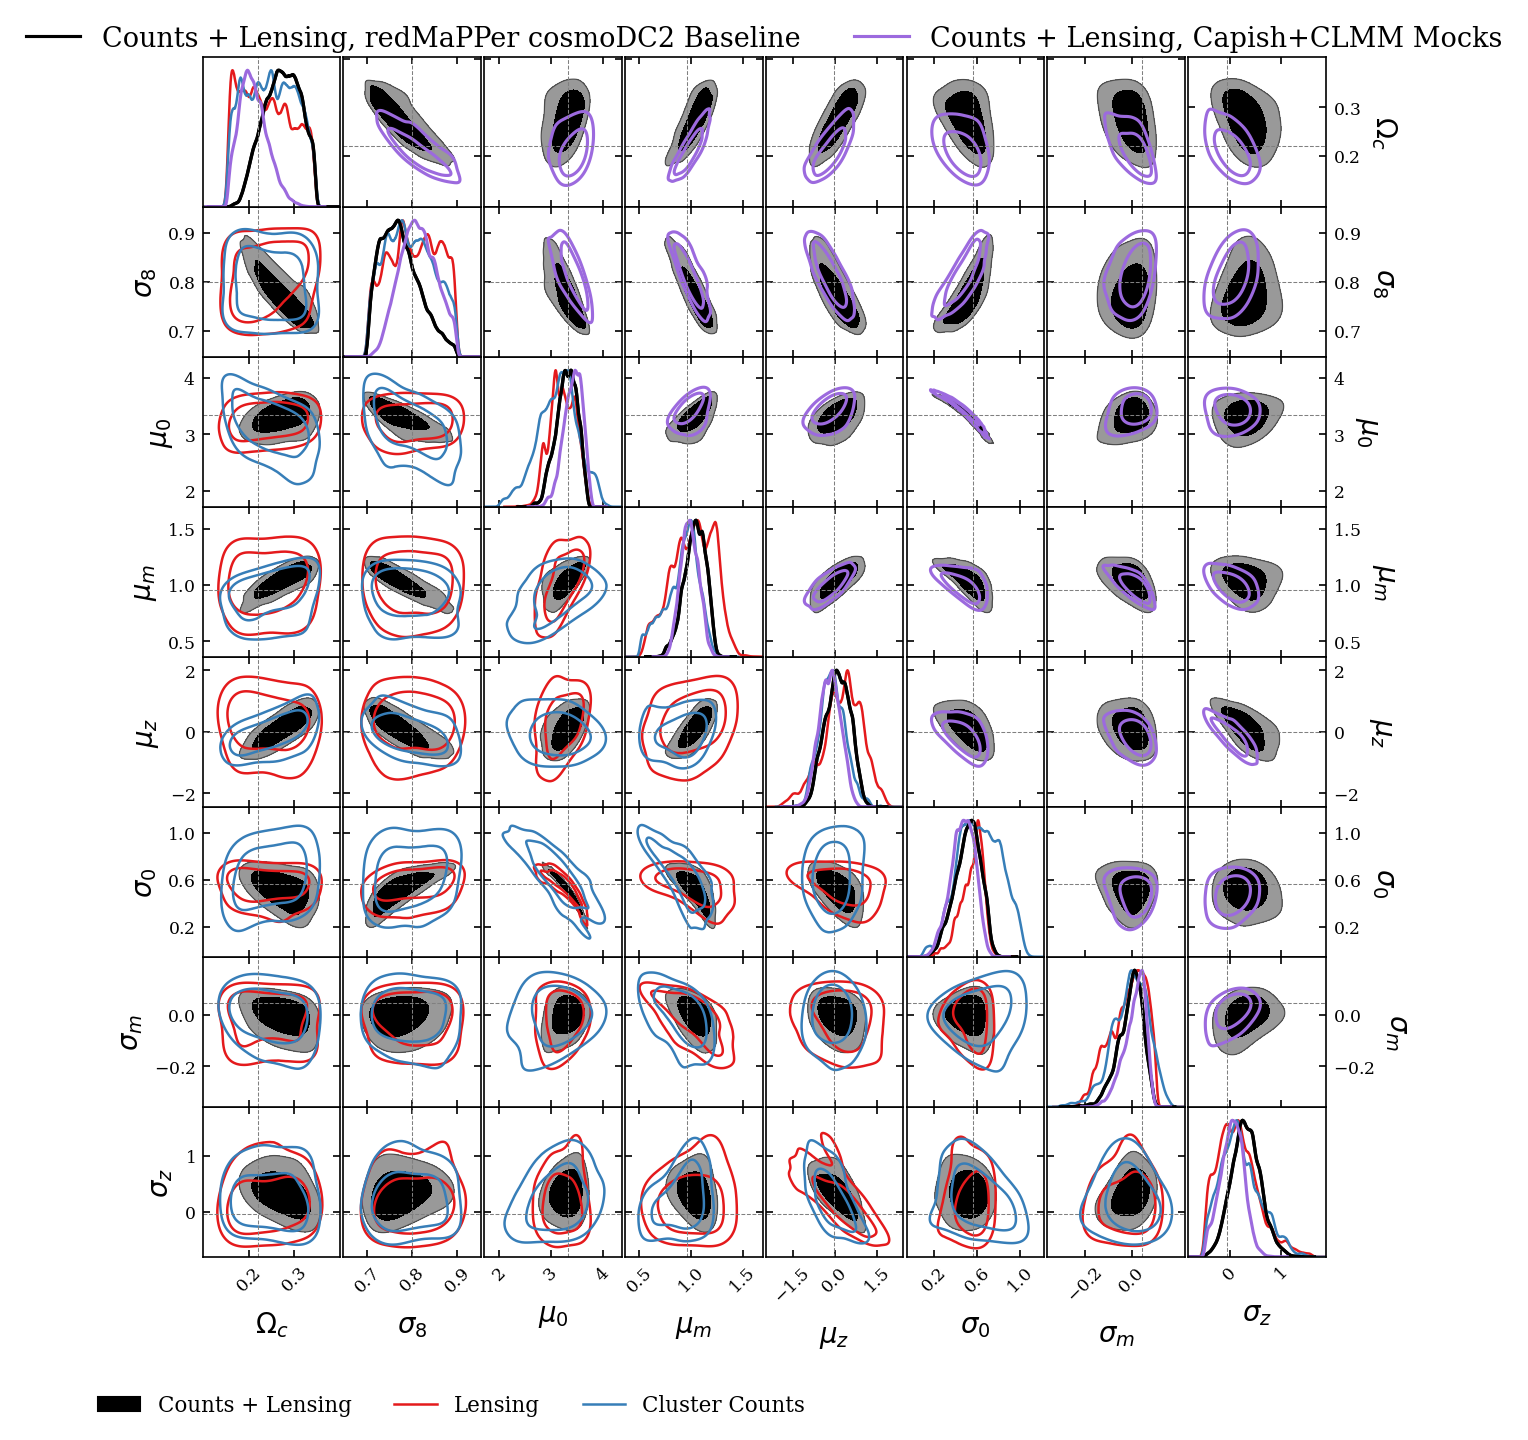


=== Lower triangle ===

── Counts + Lensing ──


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [22]:
%matplotlib inline
import sys
sys.path.append("../../")
from clpipeline.utils.cosmosis_mcmc_plots import plot_box_triangle, ChainStyle, PlotConfig

# ── Shared 8-parameter list (order matters — must match both chain sets) ──────
PARAMS_BOTH = [
    (r"\Omega_c",  0.22),
    (r"\sigma_8",  0.80),
    (r"\mu_0",     3.34),
    (r"\mu_m",     0.958236982),
    (r"\mu_z",    -0.0192802),
    (r"\sigma_0",  0.562317194),
    (r"\sigma_m",  0.04552506),
    (r"\sigma_z",  -0.0445),
]

# ── Lower triangle: baseline vs Capish mocks ───────────────────────────────────
paths_lower = [
    "/sps/lsst/users/ebarroso/CLPipeline/examples/cosmodc2_redmapper/baseline/"
    "cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt",
    "./run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt",
]

styles_lower = [
    ChainStyle("Counts + Lensing, redMaPPer cosmoDC2 Baseline",
               filled=True, fill_alpha=0.7, linewidth=1.5),
    ChainStyle("Counts + Lensing, Capish+CLMM Mocks",
               filled=False, fill_alpha=0.5, linewidth=1.5, linestyle="-", color="#9C6ADE"),
]

# ── Upper triangle: full / lensing / counts baseline decomposition ────────────
DIR = "/sps/lsst/users/ebarroso/CLPipeline/examples/cosmodc2_redmapper/baseline"

def chain(subdir, run):
    return f"{DIR}/{subdir}/run_in2p3_{run}/outputs_{run}/output_rp/number_counts_samples.txt"

SUBDIRS = {
    "full":    "cosmodc2_redmapper_full_analysis",
    "lensing": "cosmodc2_redmapper_lensing",
    "counts":  "cosmodc2_redmapper_counts",
}

paths_upper = [chain(SUBDIRS[k], "both") for k in ("full", "lensing", "counts")]

styles_upper = [
    ChainStyle("Counts + Lensing", filled=True,  linestyle="-", fill_alpha=0.8, linewidth=1.6),
    ChainStyle("Lensing",          filled=False, linestyle="-", linewidth=1.2),
    ChainStyle("Cluster Counts",   filled=False, linestyle="-", linewidth=1.2),
]

# ── Config & plot ───────────────────────────────────────────────────────────
cfg = PlotConfig(figsize=9, output_dir="./figures", burn_fraction=0.3)

samples_lower, samples_upper = plot_box_triangle(
    paths_upper, styles_upper,
    paths_lower, styles_lower,
    params=PARAMS_BOTH,
    name="box_capish_vs_baseline",
    config=cfg,
    save=True,
)
plt.show()